          Recency Frequency    Monetary      
             mean      mean        mean count
Cluster                                      
0        4.623955  1.637883  152.766226  1436
1        1.948524  3.553369  299.918213  1321
2        1.413063  1.721977  138.560079  1133
3        4.244397  1.068303   30.059669   937


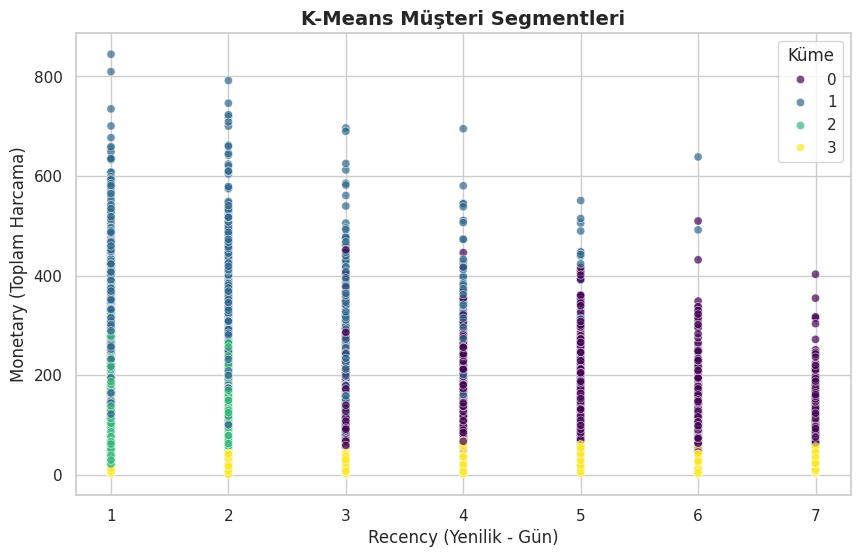

In [9]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'InvoiceNo': np.random.randint(500000, 510000, n).astype(str),
    'StockCode': np.random.choice(['22554', '21733', '85123A', '85099B', '22423'], n),
    'Description': np.random.choice(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTERS BLANKET', 'REGENCY CAKESTAND 3 TIER'], n),
    'Quantity': np.random.randint(1, 12, n),
    'InvoiceDate': pd.date_range(start='2024-01-01', periods=n, freq='min'),
    'UnitPrice': np.random.uniform(1.5, 25.0, n).round(2),
    'CustomerID': np.random.randint(12340, 18250, n),
    'Country': 'United Kingdom'
})

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

tarih = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (tarih - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
})
print(cluster_summary)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('K-Means Müşteri Segmentleri', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Yenilik - Gün)')
plt.ylabel('Monetary (Toplam Harcama)')
plt.legend(title='Küme')
plt.show()